In [5]:
import pandas as pd
import os

# Remonter à la racine du projet depuis sandbox/
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

In [ ]:

df = pd.read_parquet(r"C:\Users\jblec\FORMATIONS\CentraleSupelec - MS IA de Confiance\Cours\Composants IA à confiance maitrisée\tp-composant-ia\DATA\Original dataset\welding-detection-challenge-dataset\metadata\ds_meta.parquet",
                     engine="fastparquet")
print(df.head())
print(df.dtypes)
print(df.shape)

    sample_id class         timestamp welding-seams labelling_type  \
0  data_37966    OK  08/07/2022 02:05           c33       operator   
1  data_25403    OK  19/07/2022 00:51          c102       operator   
2  data_27038    OK  28/07/2022 16:08          c102       operator   
3   data_8767    OK    31/01/20 09:41           c33         expert   
4   data_4744    OK    25/11/19 21:57           c20         expert   

     resolution                                               path  \
0    [960, 540]  challenge-welding/datasets/welding-detection-c...   
1    [960, 540]  challenge-welding/datasets/welding-detection-c...   
2    [960, 540]  challenge-welding/datasets/welding-detection-c...   
3  [1920, 1080]  challenge-welding/datasets/welding-detection-c...   
4  [1920, 1080]  challenge-welding/datasets/welding-detection-c...   

                                              sha256 storage_type data_origin  \
0  b'0F\\\x12\xa1\x81\xcdL\xc3~\xbe\x03\xc90\x91\...           s3        real

In [3]:
df.columns

Index(['sample_id', 'class', 'timestamp', 'welding-seams', 'labelling_type',
       'resolution', 'path', 'sha256', 'storage_type', 'data_origin',
       'blur_level', 'blur_class', 'luminosity_level', 'external_path'],
      dtype='str')

In [6]:
print("Répertoire courant:", os.getcwd())

df = pd.read_parquet(r"DATA/Original dataset/welding-detection-challenge-dataset/metadata/ds_meta.parquet")
df["resolution_str"] = df["resolution"].apply(lambda x: str(list(x)))

print("=== Résolutions distinctes par (seam, labelling_type) ===")
print(df.groupby(["welding-seams", "labelling_type"])["resolution_str"].nunique())

print("\n=== Détail résolutions ===")
print(df.groupby(["welding-seams", "labelling_type", "resolution_str"]).size().to_string())

print("\n=== Effectifs par (seam, labelling_type, class) ===")
print(df.groupby(["welding-seams", "labelling_type", "class"]).size().to_string())


Répertoire courant: c:\Users\jblec\FORMATIONS\CentraleSupelec - MS IA de Confiance\Cours\Composants IA à confiance maitrisée\tp-composant-ia
=== Résolutions distinctes par (seam, labelling_type) ===
welding-seams  labelling_type
c102           expert            1
               operator          2
c20            expert            1
               operator          1
c33            expert            1
               operator          2
Name: resolution_str, dtype: int64

=== Détail résolutions ===
welding-seams  labelling_type  resolution_str                  
c102           expert          [np.int64(1920), np.int64(1080)]    4866
               operator        [np.int64(1920), np.int64(1080)]      80
                               [np.int64(960), np.int64(540)]      4006
c20            expert          [np.int64(1920), np.int64(1080)]    4841
               operator        [np.int64(1920), np.int64(1080)]      57
c33            expert          [np.int64(1920), np.int64(1080)]    5064
  

In [8]:
import torch
print(torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA disponible : True
GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU


Sample : data_9343 — c33 — KO
Résolution : (1080, 1920, 3)
Device : cuda
Nombre de masques générés : 18


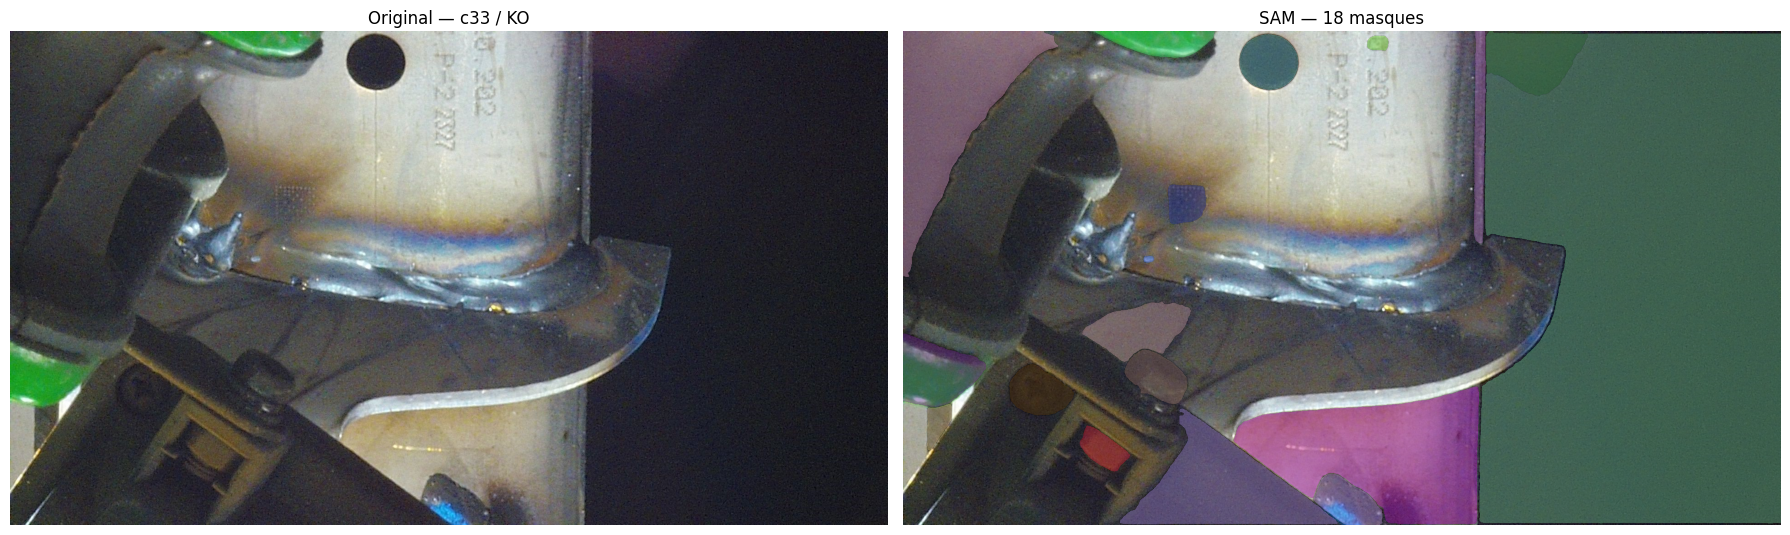

Masque 1 : area=654788 — bbox=[1260, 0, 659, 1076] — iou=0.994
Masque 2 : area=104602 — bbox=[723, 777, 536, 301] — iou=0.957
Masque 3 : area=78174 — bbox=[0, 0, 340, 537] — iou=0.970
Masque 4 : area=55711 — bbox=[474, 825, 477, 254] — iou=0.905
Masque 5 : area=23376 — bbox=[1274, 0, 223, 141] — iou=0.937


In [10]:
# 1. Installation (à lancer une fois dans le terminal)
# uv pip install segment-anything opencv-python matplotlib

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# 2. Checkpoint SAM — télécharger ViT-B (léger) depuis le repo officiel :
#    https://github.com/facebookresearch/segment-anything#model-checkpoints
#    Placer le fichier dans DATA/
SAM_CHECKPOINT = "DATA/sam_vit_b_01ec64.pth"
MODEL_TYPE = "vit_b"  # vit_b | vit_l | vit_h

# 3. Charger une image sample du dataset
import pandas as pd

# df = pd.read_parquet("DATA/Original dataset/welding-detection-challenge-dataset/metadata/ds_meta.parquet")

# Choisir un sample (modifier les filtres selon besoin)
sample = df[(df["welding-seams"] == "c33") & (df["class"] == "KO")].iloc[0]
print(f"Sample : {sample['sample_id']} — {sample['welding-seams']} — {sample['class']}")

# Construire le chemin local
seam = sample["welding-seams"]
label = sample["class"]
labelling = sample["labelling_type"]
filename = os.path.basename(sample["path"])
img_path = f"DATA/Original dataset/welding-detection-challenge-dataset/{seam}/{label}/{labelling}/{filename}"

image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print(f"Résolution : {image_rgb.shape}")

# 4. Charger SAM et générer les masques automatiquement
device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print(f"Device : {device}")

sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,        # réduire pour accélérer
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=500,  # ignorer les très petits masques
)

masks = mask_generator.generate(image_rgb)
print(f"Nombre de masques générés : {len(masks)}")

# 5. Visualisation
def show_masks(image, masks, ax):
    ax.imshow(image)
    for mask in sorted(masks, key=lambda x: x["area"], reverse=True):
        m = mask["segmentation"]
        color = np.concatenate([np.random.rand(3), [0.4]])
        h, w = m.shape
        overlay = np.zeros((h, w, 4))
        overlay[m] = color
        ax.imshow(overlay)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(image_rgb)
axes[0].set_title(f"Original — {sample['welding-seams']} / {sample['class']}")
axes[0].axis("off")

show_masks(image_rgb, masks, axes[1])
axes[1].set_title(f"SAM — {len(masks)} masques")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 6. Inspecter les masques par taille (pour identifier le cordon)
for i, mask in enumerate(sorted(masks, key=lambda x: x["area"], reverse=True)[:5]):
    bbox = mask["bbox"]  # [x, y, w, h]
    print(f"Masque {i+1} : area={mask['area']} — bbox={bbox} — iou={mask['predicted_iou']:.3f}")
